# Notebook 01 — Data Cleaning & Preprocessing
**Author:** Pasindu  
**Role:** Data Engineer  
**Task:** Load raw CSV → Upload to Hadoop HDFS → EDA → Clean & Preprocess → Save cleaned data to HDFS

---
> **Run this notebook FIRST before any other notebook.**  
> All other notebooks depend on the cleaned Parquet saved to HDFS here.

## 1. Load Packages

In [1]:
import os
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType

# Output directories
os.makedirs("output/cleaned_data", exist_ok=True)
os.makedirs("output/eda", exist_ok=True)

# Chart style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Packages loaded successfully.")

Packages loaded successfully.


## 2. Start Spark Session

In [2]:
spark = SparkSession.builder \
    .appName("RetailDataCleaning") \
    .config("spark.sql.ansi.enabled", "false") \
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY") \
    .getOrCreate()

# force ANSI off even after session creation
spark.conf.set("spark.sql.ansi.enabled", "false")

spark.sparkContext.setLogLevel("WARN")
print(f"Spark version: {spark.version}")
print("Spark session started.")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/26 12:02:39 WARN Utils: Your hostname, Pasindus-MacBook-Pro-2.local, resolves to a loopback address: 127.0.0.1; using 10.16.139.13 instead (on interface en0)
26/04/26 12:02:39 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/26 12:02:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/26 12:02:44 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/04/26 12:02:44 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


Spark version: 4.1.1
Spark session started.


In [3]:
# fix timestamp parsing — must run before any df operations
spark.conf.set("spark.sql.ansi.enabled", "false")
spark.conf.set("spark.sql.legacy.timeParserPolicy", "LEGACY")

# verify settings applied
print("ansi.enabled         :", spark.conf.get("spark.sql.ansi.enabled"))
print("timeParserPolicy     :", spark.conf.get("spark.sql.legacy.timeParserPolicy"))

ansi.enabled         : false
timeParserPolicy     : LEGACY


## 3. Upload Raw Dataset to Hadoop HDFS
We create directories in HDFS then upload the raw CSV.  
This is the **only time** we read from local disk — all other notebooks use HDFS.

In [4]:
# ── Path to raw CSV on your local machine ─────────────────────────────────────
LOCAL_RAW_CSV = "/Users/pasindumalinda/Project-04/ecommerce-recommendation-spark/data/raw/online_retail_II.csv"

# ── HDFS paths ────────────────────────────────────────────────────────────────
HDFS_RAW_DIR     = "hdfs://localhost:8020/retail/raw/"
HDFS_CLEANED_DIR = "hdfs://localhost:8020/retail/cleaned/"

# ── Create HDFS directories ───────────────────────────────────────────────────
subprocess.run(["hdfs", "dfs", "-mkdir", "-p", "/retail/raw"],     check=True)
subprocess.run(["hdfs", "dfs", "-mkdir", "-p", "/retail/cleaned"], check=True)

# ── Upload raw CSV ────────────────────────────────────────────────────────────
subprocess.run(
    ["hdfs", "dfs", "-put", "-f", LOCAL_RAW_CSV, "/retail/raw/"],
    check=True
)
print(f"Raw CSV uploaded to HDFS: {HDFS_RAW_DIR}")

2026-04-26 12:02:45,694 WARN util.NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
2026-04-26 12:02:46,244 WARN util.NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
2026-04-26 12:02:46,735 WARN util.NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Raw CSV uploaded to HDFS: hdfs://localhost:8020/retail/raw/


## 4. Load Raw Dataset from HDFS

In [5]:
# Read the raw CSV from HDFS
df_raw = spark.read.csv(
    "hdfs://localhost:8020/retail/raw/online_retail_II.csv",
    header=True,
    inferSchema=True
)

# Rename columns for consistency across all notebooks
df_raw = df_raw \
    .withColumnRenamed("Customer ID", "CustomerID") \
    .withColumnRenamed("Price", "UnitPrice")

raw_count = df_raw.count()
print(f"Raw record count: {raw_count:,}")

Raw record count: 1,067,371


---
# Exploratory Data Analysis (EDA)
Before cleaning, we explore the raw data to understand its structure, quality, and distribution.
---

## 5. Schema & Sample Rows

In [6]:
# Column names and their data types
print("Schema:")
df_raw.printSchema()

Schema:
root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: double (nullable = true)
 |-- Country: string (nullable = true)



In [7]:
# First 5 rows — get a feel for the data
df_raw.show(5, truncate=True)

+-------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|
+-------+---------+--------------------+--------+-------------------+---------+----------+--------------+
| 489434|    85048|15CM CHRISTMAS GL...|      12|2009-12-01 07:45:00|     6.95|   13085.0|United Kingdom|
| 489434|   79323P|  PINK CHERRY LIGHTS|      12|2009-12-01 07:45:00|     6.75|   13085.0|United Kingdom|
| 489434|   79323W| WHITE CHERRY LIGHTS|      12|2009-12-01 07:45:00|     6.75|   13085.0|United Kingdom|
| 489434|    22041|"RECORD FRAME 7""...|      48|2009-12-01 07:45:00|      2.1|   13085.0|United Kingdom|
| 489434|    21232|STRAWBERRY CERAMI...|      24|2009-12-01 07:45:00|     1.25|   13085.0|United Kingdom|
+-------+---------+--------------------+--------+-------------------+---------+----------+--------------+
only showing top 5 rows


## 6. Missing Values Analysis

In [8]:
# Count nulls in every column
null_counts = df_raw.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df_raw.columns
]).toPandas().T.rename(columns={0: "Null Count"})

null_counts["Null %"] = (null_counts["Null Count"] / raw_count * 100).round(2)
print("Null values per column:")
print(null_counts.to_string())

Null values per column:
             Null Count  Null %
Invoice               0    0.00
StockCode             0    0.00
Description        4382    0.41
Quantity              0    0.00
InvoiceDate           0    0.00
UnitPrice             0    0.00
CustomerID       243007   22.77
Country               0    0.00


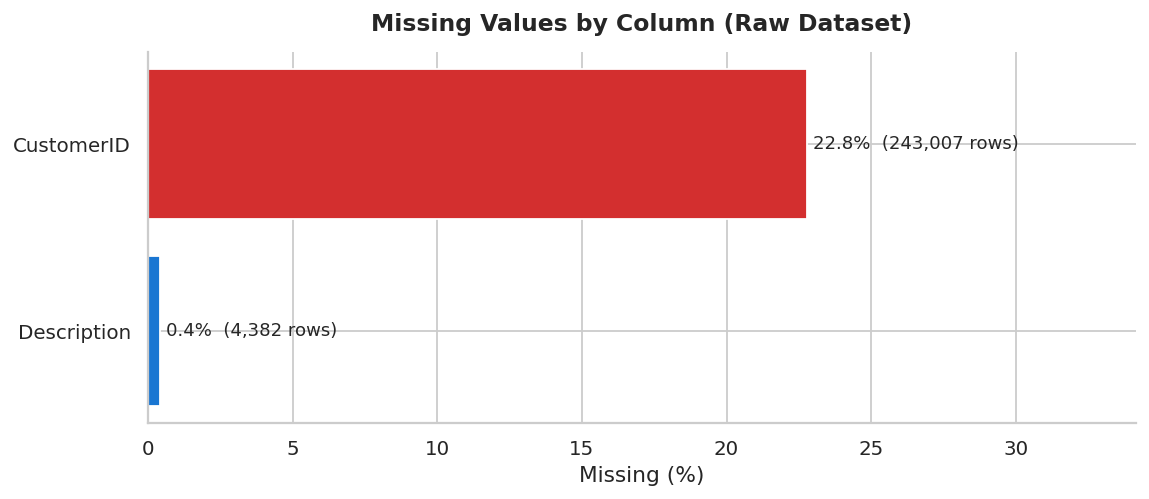

Chart saved.


In [9]:
# Bar chart of null percentages
fig, ax = plt.subplots(figsize=(9, 4))

cols_with_nulls = null_counts[null_counts["Null Count"] > 0]
colors = ["#D32F2F" if v > 10 else "#1976D2" for v in cols_with_nulls["Null %"]]
ax.barh(cols_with_nulls.index, cols_with_nulls["Null %"], color=colors, edgecolor="white")

# Add percentage labels
for i, (val, cnt) in enumerate(zip(cols_with_nulls["Null %"], cols_with_nulls["Null Count"])):
    ax.text(val + 0.2, i, f"{val:.1f}%  ({cnt:,} rows)", va="center", fontsize=10)

ax.set_title("Missing Values by Column (Raw Dataset)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Missing (%)")
ax.set_xlim(0, max(cols_with_nulls["Null %"]) * 1.5)
plt.tight_layout()
plt.savefig("output/eda/eda_null_values.png", bbox_inches="tight")
plt.show()
print("Chart saved.")

**Finding:** `CustomerID` has the most nulls (~24.9% of rows). `Description` also has a small number of nulls. These rows will be removed during cleaning as they cannot be used for customer-level or product-level analysis.

## 7. Descriptive Statistics

In [10]:
# Summary statistics for numeric columns
print("Descriptive statistics (raw data):")
df_raw.select("Quantity", "UnitPrice").describe().show()

Descriptive statistics (raw data):
+-------+------------------+------------------+
|summary|          Quantity|         UnitPrice|
+-------+------------------+------------------+
|  count|           1067371|           1067371|
|   mean|   9.9388984711033| 4.649387727415796|
| stddev|172.70579407675396|123.55305872146369|
|    min|            -80995|         -53594.36|
|    max|             80995|           38970.0|
+-------+------------------+------------------+



In [11]:
# Count rows with invalid values that need to be removed
n_cancelled    = df_raw.filter(F.col("Invoice").startswith("C")).count()
n_neg_qty      = df_raw.filter(F.col("Quantity") <= 0).count()
n_zero_price   = df_raw.filter(F.col("UnitPrice") <= 0).count()
n_null_cust    = df_raw.filter(F.col("CustomerID").isNull()).count()
n_null_desc    = df_raw.filter(F.col("Description").isNull()).count()

print(f"Cancelled invoices (start with C) : {n_cancelled:>10,}")
print(f"Rows with Quantity <= 0           : {n_neg_qty:>10,}")
print(f"Rows with UnitPrice <= 0          : {n_zero_price:>10,}")
print(f"Rows missing CustomerID           : {n_null_cust:>10,}")
print(f"Rows missing Description          : {n_null_desc:>10,}")

Cancelled invoices (start with C) :     19,494
Rows with Quantity <= 0           :     22,950
Rows with UnitPrice <= 0          :      6,207
Rows missing CustomerID           :    243,007
Rows missing Description          :      4,382


## 8. Unique Value Counts

In [12]:
# Count distinct values in key columns
cols_to_check = ["Invoice", "StockCode", "Description", "CustomerID", "Country"]
for col_name in cols_to_check:
    cnt = df_raw.select(col_name).distinct().count()
    print(f"  Unique {col_name:<15}: {cnt:>8,}")

  Unique Invoice        :   53,628
  Unique StockCode      :    5,305
  Unique Description    :    5,699
  Unique CustomerID     :    5,943
  Unique Country        :       43


## 9. Top Countries & Date Range

In [13]:
# Top 10 countries by transaction count in the raw data
top_countries_raw = df_raw.groupBy("Country") \
    .count() \
    .orderBy(F.col("count").desc()) \
    .limit(10) \
    .toPandas()

print("Top 10 countries by number of rows (raw):")
print(top_countries_raw.to_string(index=False))

Top 10 countries by number of rows (raw):
       Country  count
United Kingdom 981330
          EIRE  17866
       Germany  17624
        France  14330
   Netherlands   5140
         Spain   3811
   Switzerland   3189
       Belgium   3123
      Portugal   2620
     Australia   1913


In [14]:
# Date range of the dataset
date_range = df_raw.select(
    F.min("InvoiceDate").alias("Earliest"),
    F.max("InvoiceDate").alias("Latest")
).toPandas()

print(f"Date range: {date_range['Earliest'][0]}  →  {date_range['Latest'][0]}")

Date range: 2009-12-01 07:45:00  →  2011-12-09 12:50:00


## 10. Quantity Distribution (EDA Chart)

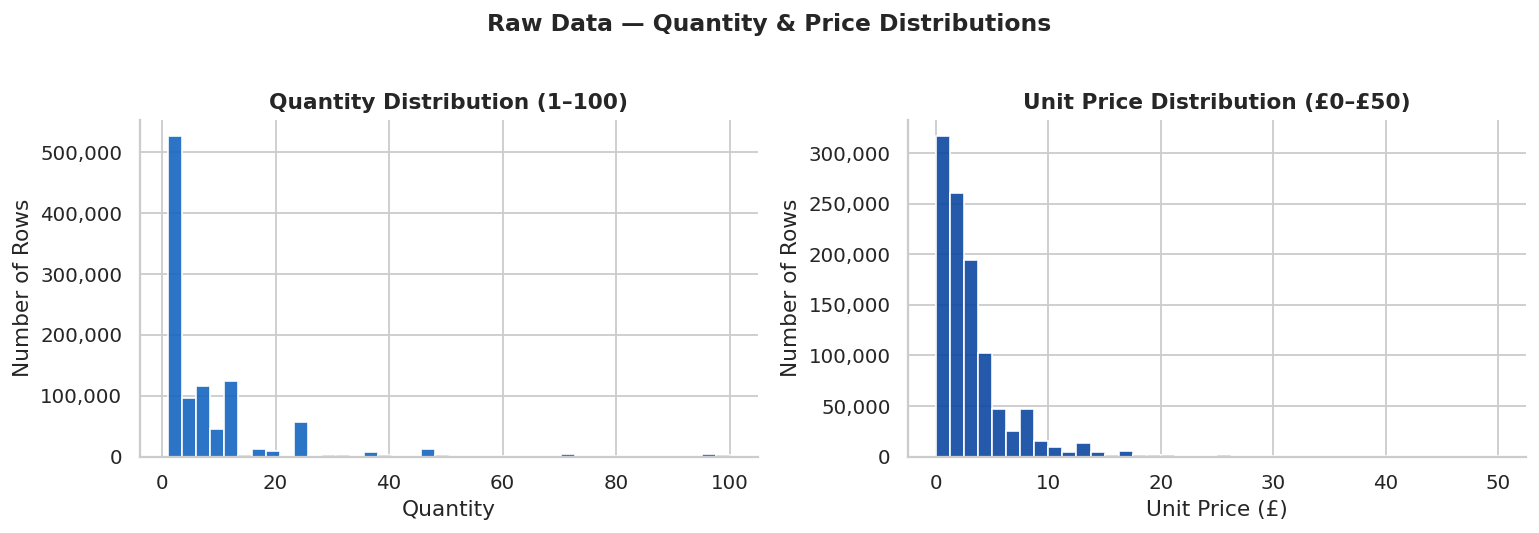

EDA distribution chart saved.


In [15]:
# Distribution of positive Quantity values (cap at 100 to remove extreme outliers for display)
qty_data = df_raw.filter(
    (F.col("Quantity") > 0) & (F.col("Quantity") <= 100)
).select("Quantity").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of Quantity
axes[0].hist(qty_data["Quantity"], bins=40, color="#1565C0", edgecolor="white", alpha=0.9)
axes[0].set_title("Quantity Distribution (1–100)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Quantity")
axes[0].set_ylabel("Number of Rows")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# UnitPrice distribution (cap at £50)
price_data = df_raw.filter(
    (F.col("UnitPrice") > 0) & (F.col("UnitPrice") <= 50)
).select("UnitPrice").toPandas()

axes[1].hist(price_data["UnitPrice"], bins=40, color="#0D47A1", edgecolor="white", alpha=0.9)
axes[1].set_title("Unit Price Distribution (£0–£50)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Unit Price (£)")
axes[1].set_ylabel("Number of Rows")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("Raw Data — Quantity & Price Distributions", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("output/eda/eda_distributions.png", bbox_inches="tight")
plt.show()
print("EDA distribution chart saved.")

**Finding:** Both Quantity and UnitPrice are heavily right-skewed. The vast majority of orders are for small quantities (1–12 units) at low prices (under £5). A small number of bulk orders create extreme outliers that would distort analyses if not handled.

---
# Data Cleaning & Preprocessing
---

## 11. Apply Cleaning Steps

In [16]:
# Step 1: Remove rows with missing CustomerID or Description
# These rows cannot be used for customer or product-level analysis
df = df_raw.dropna(subset=["CustomerID", "Description"])
print(f"After removing null CustomerID/Description: {df.count():,} rows")

After removing null CustomerID/Description: 824,364 rows


In [17]:
# Step 2: Remove cancelled orders (Invoice starts with 'C')
# Cancellations are returns and should not be treated as purchases
df = df.filter(~F.col("Invoice").cast("string").startswith("C"))
print(f"After removing cancellations: {df.count():,} rows")

After removing cancellations: 805,620 rows


In [18]:
# Step 3: Remove rows with invalid Quantity or UnitPrice
# Zero or negative values indicate data errors or refunds
df = df.filter((F.col("Quantity") > 0) & (F.col("UnitPrice") > 0))
print(f"After removing invalid Quantity/Price: {df.count():,} rows")

After removing invalid Quantity/Price: 805,549 rows


In [19]:
# Step 4: Remove duplicate rows
df = df.dropDuplicates()
print(f"After removing duplicates: {df.count():,} rows")

After removing duplicates: 779,425 rows


In [20]:
# Step 5: Fix data types

# disable ANSI mode to allow flexible timestamp parsing
spark.conf.set("spark.sql.ansi.enabled", "false")

# parse InvoiceDate — actual format in CSV is "yyyy-MM-dd HH:mm:ss"
# use try_to_timestamp to return NULL instead of crashing on bad dates
df = df.withColumn(
    "InvoiceDate",
    F.expr("try_to_timestamp(InvoiceDate, 'yyyy-MM-dd HH:mm:ss')")
)

# cast CustomerID to integer (removes the trailing .0)
df = df.withColumn("CustomerID", F.col("CustomerID").cast(IntegerType()))

# verify — null count should be 0 or very small
null_ts = df.filter(F.col("InvoiceDate").isNull()).count()
print(f"Null InvoiceDate after parsing: {null_ts:,}")
print("Data types corrected.")

Null InvoiceDate after parsing: 0
Data types corrected.


In [21]:
# Step 6: Add derived date columns for use in analysis notebooks
df = df \
    .withColumn("Year",      F.year("InvoiceDate")) \
    .withColumn("Month",     F.month("InvoiceDate")) \
    .withColumn("DayOfWeek", F.dayofweek("InvoiceDate")) \
    .withColumn("Hour",      F.hour("InvoiceDate")) \
    .withColumn("YearMonth", F.date_format("InvoiceDate", "yyyy-MM"))

# Step 7: Add TotalPrice = Quantity × UnitPrice
df = df.withColumn(
    "TotalPrice",
    F.round(F.col("Quantity") * F.col("UnitPrice"), 2)
)

print("Derived columns added: Year, Month, DayOfWeek, Hour, YearMonth, TotalPrice")

Derived columns added: Year, Month, DayOfWeek, Hour, YearMonth, TotalPrice


## 12. Verify Cleaned Data

In [22]:
# Check the final schema
df.printSchema()

root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- DayOfWeek: integer (nullable = true)
 |-- Hour: integer (nullable = true)
 |-- YearMonth: string (nullable = true)
 |-- TotalPrice: double (nullable = true)



In [23]:
# Preview cleaned data
df.show(5, truncate=True)

+-------+---------+--------------------+--------+-------------------+---------+----------+--------------+----+-----+---------+----+---------+----------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|Year|Month|DayOfWeek|Hour|YearMonth|TotalPrice|
+-------+---------+--------------------+--------+-------------------+---------+----------+--------------+----+-----+---------+----+---------+----------+
| 489437|    10002|INFLATABLE POLITI...|      12|2009-12-01 09:08:00|     0.85|     15362|United Kingdom|2009|   12|        3|   9|  2009-12|      10.2|
| 489465|   72760B|VINTAGE CREAM 3 B...|       4|2009-12-01 10:52:00|     9.95|     13767|United Kingdom|2009|   12|        3|  10|  2009-12|      39.8|
| 489465|    84879|ASSORTED COLOUR B...|     160|2009-12-01 10:52:00|     1.45|     13767|United Kingdom|2009|   12|        3|  10|  2009-12|     232.0|
| 489517|    21584|RETRO SPOT SMALL ...|      20|2009-12-01 11:34:00|     1.65|   

In [24]:
# Summary statistics on cleaned numeric columns
df.select("Quantity", "UnitPrice", "TotalPrice").describe().show()

# Confirm no nulls remain in key columns
print("Remaining nulls in key columns:")
df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in ["Invoice", "CustomerID", "Quantity", "UnitPrice", "TotalPrice"]
]).show()

+-------+------------------+------------------+------------------+
|summary|          Quantity|         UnitPrice|        TotalPrice|
+-------+------------------+------------------+------------------+
|  count|            779425|            779425|            779425|
|   mean|13.489369727683869| 3.218487985375475| 22.29182313884957|
| stddev| 145.8558140997767|29.676139695711434|227.42707548583434|
|    min|                 1|             0.001|               0.0|
|    max|             80995|           10953.5|          168469.6|
+-------+------------------+------------------+------------------+

Remaining nulls in key columns:


+-------+----------+--------+---------+----------+
|Invoice|CustomerID|Quantity|UnitPrice|TotalPrice|
+-------+----------+--------+---------+----------+
|      0|         0|       0|        0|         0|
+-------+----------+--------+---------+----------+



In [25]:
# Before vs After row count summary
cleaned_count = df.count()
removed       = raw_count - cleaned_count

print("=" * 45)
print(f"  Raw records      : {raw_count:>10,}")
print(f"  Cleaned records  : {cleaned_count:>10,}")
print(f"  Records removed  : {removed:>10,}")
print(f"  Data retained    : {cleaned_count/raw_count*100:>9.1f}%")
print("=" * 45)

  Raw records      :  1,067,371
  Cleaned records  :    779,425
  Records removed  :    287,946
  Data retained    :      73.0%


## 13. Save Cleaned Data — HDFS & Local

In [26]:
# Save to HDFS as Parquet — faster to read than CSV, preserves column types
df.write.parquet(
    "hdfs://localhost:8020/retail/cleaned/",
    mode="overwrite"
)
print("Cleaned data saved to HDFS: hdfs://localhost:8020/retail/cleaned/")

26/04/26 12:03:08 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers


Cleaned data saved to HDFS: hdfs://localhost:8020/retail/cleaned/


In [27]:
# Save a local CSV copy and schema file for reference
df.toPandas().to_csv("output/cleaned_data/retail_cleaned_full.csv", index=False)

schema_str = df.schema.json()
with open("output/cleaned_data/schema.json", "w") as f:
    f.write(schema_str)

print("Full CSV saved:    output/cleaned_data/retail_cleaned_full.csv")
print("Schema saved:      output/cleaned_data/schema.json")

Full CSV saved:    output/cleaned_data/retail_cleaned_full.csv
Schema saved:      output/cleaned_data/schema.json


In [28]:
# Read back from HDFS to confirm the save was successful
df_check = spark.read.parquet("hdfs://localhost:8020/retail/cleaned/")
print(f"HDFS read-back count : {df_check.count():,} rows")
print(f"Columns              : {df_check.columns}")
print("\nNotebook 01 complete. All other notebooks can now load from HDFS.")

HDFS read-back count : 779,425 rows
Columns              : ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Year', 'Month', 'DayOfWeek', 'Hour', 'YearMonth', 'TotalPrice']

Notebook 01 complete. All other notebooks can now load from HDFS.


---
## Summary

| Step | Action | Design Pattern |
|------|--------|----------------|
| 1 | Upload raw CSV to HDFS | Data Ingestion |
| 2 | EDA — nulls, stats, distributions | Exploration |
| 3 | Remove null CustomerID / Description | Filtering |
| 4 | Remove cancelled orders (Invoice starts with C) | Filtering |
| 5 | Remove Quantity ≤ 0 and UnitPrice ≤ 0 | Filtering |
| 6 | Remove duplicate rows | Deduplication |
| 7 | Parse dates, extract Year/Month/Day/Hour | Transformation |
| 8 | Add TotalPrice = Quantity × UnitPrice | Transformation |
| 9 | Save cleaned Parquet to HDFS + local CSV | Output |